Loading necessary libraries

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import timedelta
import matplotlib.pyplot as plt

import jutuldarcy as jd
from juliacall import Main as jl
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("..")

from deepfield import Field

C:\Users\mushe\anaconda3\envs\deepfield\Lib\site-packages\jutuldarcy\julia_import.py:9: UserWarning: juliacall module already imported. Make sure that you have set the environment variable `PYTHON_JULIACALL_HANDLE_SIGNALS=yes` to avoid segfaults. Also note that jutuldarcy will not be able to configure `PYTHON_JULIACALL_THREADS` or `PYTHON_JULIACALL_OPTLEVEL` for you.
  warnings.warn(


Downloading `.DATA` file using jutuldarcy functionality

In [5]:
path = '../open_data/egg/Egg_Model_ECL.DATA'

In [6]:
case = jd.setup_case_from_data_file(path)

Extracting initial state

In [7]:
state0_pressure = np.array(
    jl.seval("state0 -> state0[:Reservoir][:Pressure]")(case.state0)
).reshape(1, -1)

state0_sats = np.array(
    jl.seval("state0 -> state0[:Reservoir][:Saturations]")(case.state0)
).reshape(1, 2, -1)

Downloading the same model using deepfield functionality

In [8]:
model = Field(path).load()

INFO:Field:Using default config.
INFO:Field:Start reading Egg_Model_ECL.DATA
INFO:Field:Reading section RUNSPEC
INFO:Field:[Egg_Model_ECL.DATA:9] Loading TITLE
INFO:Field:[Egg_Model_ECL.DATA:16] Loading DIMENS
INFO:Field:[Egg_Model_ECL.DATA:19] Loading METRIC
INFO:Field:[Egg_Model_ECL.DATA:20] Loading OIL
INFO:Field:[Egg_Model_ECL.DATA:21] Loading WATER
INFO:Field:[Egg_Model_ECL.DATA:41] Loading START
INFO:Field:Reading section GRID
INFO:Field:[Egg_Model_ECL.DATA:55] Include D:\RnD\StudyProjects\deepfield-team\DeepField\open_data\egg\ACTIVE.INC
INFO:Field:Start reading ACTIVE.INC
INFO:Field:[ACTIVE.INC:1] Loading ACTNUM
INFO:Field:Finish reading ACTIVE.INC
INFO:Field:[Egg_Model_ECL.DATA:58] Loading DX
INFO:Field:[Egg_Model_ECL.DATA:62] Loading DY
INFO:Field:[Egg_Model_ECL.DATA:66] Loading DZ
INFO:Field:[Egg_Model_ECL.DATA:69] Loading TOPS
INFO:Field:[Egg_Model_ECL.DATA:73] Include D:\RnD\StudyProjects\deepfield-team\DeepField\open_data\egg\mDARCY.INC
INFO:Field:Start reading mDARCY.INC

Simulate case using jutuldarcy functionality

In [9]:
res = jd.simulate_data_file(path, convert = True)

Jutul: Simulating 9 years, 44.69 weeks as 120 report steps


Progress   2%|█                                          |  ETA: 0:27:07
   Progress: Solving step 2/120 (1.67% of time interval complete)
   Stats: 34 iterations in 25.61 s (753.17 ms each)

Progress   2%|██                                         |  ETA: 0:19:40
   Progress: Solving step 3/120 (2.50% of time interval complete)
   Stats: 49 iterations in 27.42 s (559.58 ms each)

Progress   3%|██                                         |  ETA: 0:15:12
   Progress: Solving step 4/120 (3.33% of time interval complete)
   Stats: 59 iterations in 28.57 s (484.15 ms each)

Progress   4%|██                                         |  ETA: 0:12:29
   Progress: Solving step 5/120 (4.17% of time interval complete)
   Stats: 69 iterations in 29.66 s (429.85 ms each)

Progress   5%|███                                        |  ETA: 0:10:44
   Progress: Solving step 6/120 (5.00% of time interval complete)
   Stats: 80 iterations in 30.98 s (387.22 ms each)

Progress   6%|███                       

╭────────────────┬───────────┬───────────────┬──────────╮
│ Iteration type │  Avg/step │  Avg/ministep │    Total │
│                │ 120 steps │ 154 ministeps │ (wasted) │
├────────────────┼───────────┼───────────────┼──────────┤
│ Newton         │   4.35833 │        3.3961 │  523 (0) │
│ Linearization  │   5.64167 │        4.3961 │  677 (0) │
│ Linear solver  │   20.8417 │       16.2403 │ 2501 (0) │
│ Precond apply  │   41.6833 │       32.4805 │ 5002 (0) │
╰────────────────┴───────────┴───────────────┴──────────╯
╭───────────────┬──────────┬────────────┬─────────╮
│ Timing type   │     Each │   Relative │   Total │
│               │       ms │ Percentage │       s │
├───────────────┼──────────┼────────────┼─────────┤
│ Properties    │   4.3578 │     2.51 % │  2.2791 │
│ Equations     │  13.6074 │    10.15 % │  9.2122 │
│ Assembly      │   8.5320 │     6.37 % │  5.7762 │
│ Linear solve  │  12.1965 │     7.03 % │  6.3787 │
│ Linear setup  │  60.4859 │    34.86 % │ 31.6341 │
│ Precond 

Draw mean pressure and saturations calculated by jutuldarcy

In [15]:
n_steps = len(res['STATES'])
jd_pressure = np.array([res['STATES'][i]['Pressure'] for i in range(n_steps)])
jd_sats = np.array([res['STATES'][i]['Saturations'] for i in range(n_steps)])

In [16]:
df_pressure = np.vstack([state0_pressure, jd_pressure])
df_sats = np.vstack([state0_sats, jd_sats])

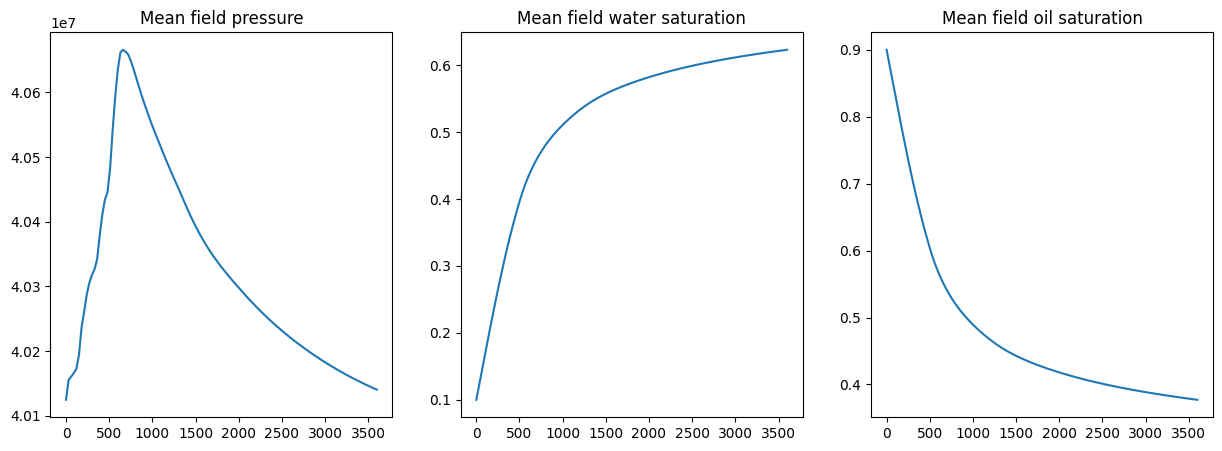

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

days = np.hstack([0., res["DAYS"]])
pressure = df_pressure.mean(axis=1)
swat = df_sats[:, 0, :].mean(axis=1)
soil = df_sats[:, 1, :].mean(axis=1)

ax[0].set_title("Mean field pressure")
ax[0].plot(days, pressure)
ax[1].set_title("Mean field water saturation")
ax[1].plot(days, swat)
ax[2].set_title("Mean field oil saturation")
ax[2].plot(days, soil)

Model downloaded as Field object doesn't contain states

In [18]:
model.states.attributes

()

Let's assign computed by JutulDarcy states to deepfield's model

In [19]:
model.states.pressure = df_pressure

In [20]:
model.states.soil = df_sats[:, 1, :]

In [21]:
model.states.swat = df_sats[:, 0, :]

In [22]:
model.states.to_spatial()

Then we can visualize state attributes

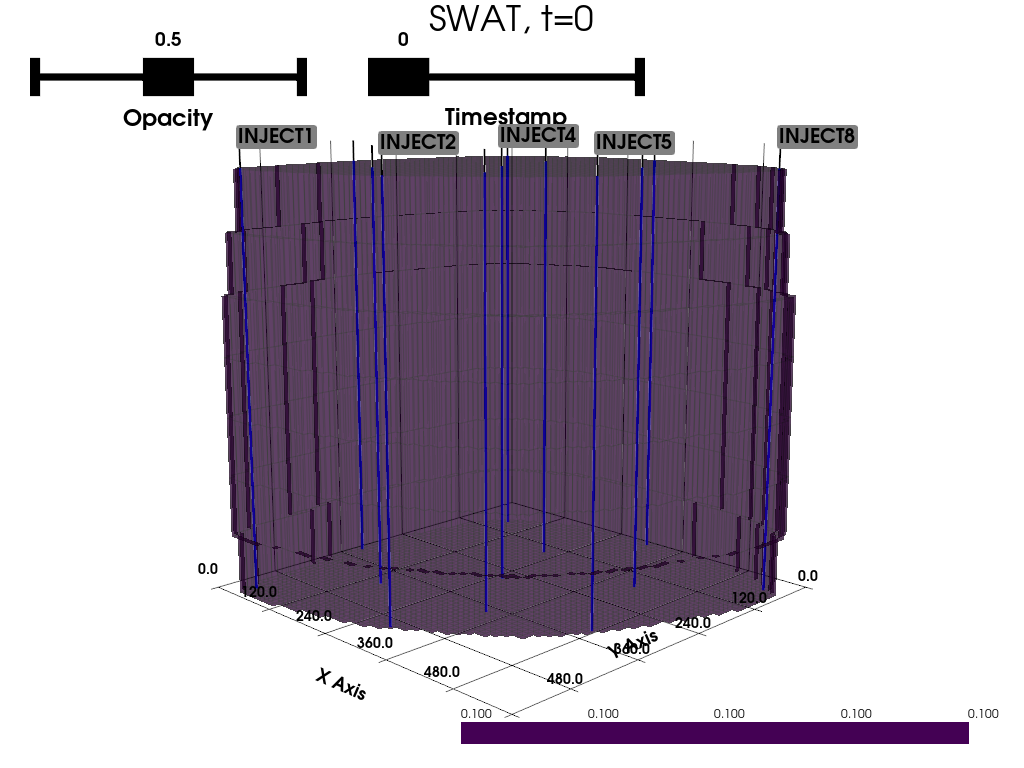

In [25]:
model.show(attr="SWAT", notebook=True)

States also include computed well rates

In [26]:
n_timestamps = len(res["DAYS"])

In [27]:
start_date = case.input_data["RUNSPEC"]["START"]
timestamps = [start_date + timedelta(days=res["DAYS"][i]) for i in range(n_timestamps)]
dates = pd.DataFrame({"DATE": timestamps})

Creating `welldata` structure

In [28]:
welldata = {}

Utility function for collecting computed well rates into dataframe

In [30]:
def results(well_df):
    results_df = pd.concat([dates, pd.DataFrame(well_df)], axis=1)
    record0 = pd.DataFrame([[start_date] + [0.0]*(len(well_df.columns))], columns = results_df.columns)
    results_df = pd.concat([record0, results_df])
    return results_df

In [31]:
wellnames = res["WELLS"].keys()
welldata = {w: {"RESULTS": results(pd.DataFrame(res["WELLS"][w]))} for w in wellnames}

Assigning `welldata` structure to wells by `wells.update` method

In [32]:
model.wells.update(welldata)

Now it is possible to show well rates as a part of Field model

In [33]:
model.wells.show_rates()

interactive(children=(Dropdown(description='wellname', options=('FIELD', '1', 'INJECT1', 'INJECT2', 'INJECT3',…